In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

In [2]:
# Wind speed and angle
v = 10
phi = np.pi/4

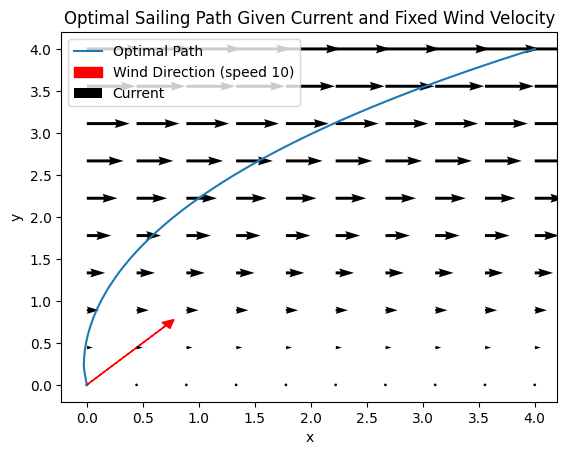

In [3]:
# Building drift, change in drift, and the ode to solve
def w(x, y):
    x, y = np.atleast_1d(x), np.atleast_1d(y)
    return np.vstack((5*y, np.zeros_like(y)))

def dw(x, y):
    return np.array([
        [0, 2],
        [0, 0]
    ])

# Building the ODE
def ode(t, Y, p):
    T = p[0]

    x, y, l1, l2 = Y
    lnorm = np.sqrt(l1**2 + l2**2) + 1e-10

    theta = np.arctan2(l2, l1)  # optimal heading points along lambda
    u1 = v * np.cos(theta - phi) * np.cos(theta)
    u2 = v * np.cos(theta - phi) * np.sin(theta)

    w1, w2 = w(x, y)
  
    dx = T * (u1 + w1)
    dy = T * (u2 + w2)

    Dw = dw(x, y)
    dl1, dl2 = -T * (Dw.T @ np.array([l1, l2]))

    return np.array([dx, dy, dl1, dl2])

# The initial and final state
x0 = np.array([0, 0])
xf = np.array([4, 4])

# The boundary conditions
def bc(ya, yb, p):
    T = p[0]

    xa, ya_val, l1a, l2a = ya
    xb, yb_val, l1b, l2b = yb

    lam_norm = np.sqrt(l1b**2 + l2b**2) + 1e-10
    
    theta_b = np.arctan2(l2b, l1b)
    u1b = v * np.cos(theta_b - phi) * np.cos(theta_b)
    u2b = v * np.cos(theta_b - phi) * np.sin(theta_b)
    
    wb = w(xb, yb_val).flatten()
    
    Hf = l1b * (u1b + wb[0]) + l2b * (u2b + wb[1]) - 1.0

    return np.array([
        xa - x0[0],
        ya_val - x0[1],
        xb - xf[0],
        yb_val - xf[1],
        Hf
    ])

# Computing the optimal route
t = np.linspace(0, 1, 100)

# Initial guesses
Y_guess = np.zeros((4, t.size))
p_guess = np.array([2.0])
Y_guess[0] = np.linspace(x0[0], xf[0], t.size)
Y_guess[1] = np.linspace(x0[1], xf[1], t.size)
Y_guess[2] = 1.0
Y_guess[3] = 1.0

# Solving the ode
sol = solve_bvp(ode, bc, t, Y_guess, p=p_guess)

# Plotting the optimally computed path
plt.plot(sol.y[0], sol.y[1], label="Optimal Path")

# Plotting the wind direction
plt.arrow(0, 0, np.cos(phi), np.sin(phi), head_width=0.1, head_length=0.1, fc="red", ec="red", label=f"Wind Direction (speed {v})")

# Plotting the vector field and optimal route
x = np.linspace(0, 4, 10)
X, Y = np.meshgrid(x, x)
U = 5 * Y
V = np.zeros_like(X)
plt.quiver(X, Y, U, V, label="Current")
plt.title("Optimal Sailing Path Given Current and Fixed Wind Velocity")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()